##### Name: Muhammad Huzaifa
##### Roll No: SU92-BSAIM-S4-010
##### Section: 4A
##### Subject: AI Lab Task

# ---------Task 5----------

## Import:

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def show_bgr(img, title=""):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,4)); plt.imshow(img_rgb); plt.title(title); plt.axis('off')


## Read & write image

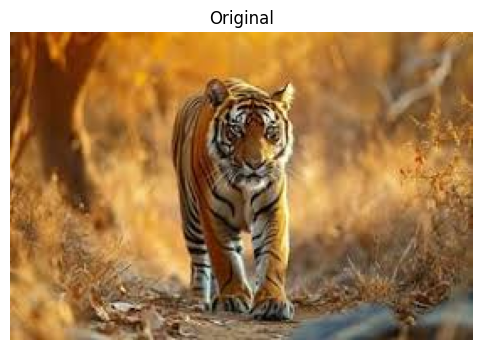

In [2]:
img = cv2.imread("sample.jpeg")
if img is None:
    print("Image not found — put an image at images/test.jpg")
else:
    show_bgr(img, "Original")
    cv2.imwrite("output.jpg", img)


## Resize & Crop

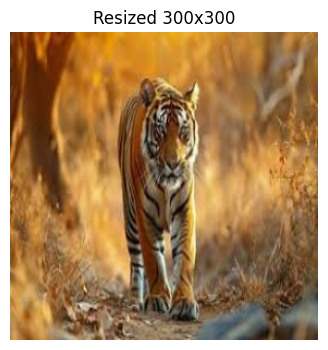

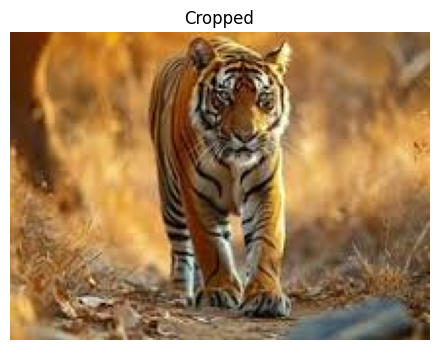

In [3]:
resized = cv2.resize(img, (300, 300))    
cropped = img[25:200, 25:240]            
show_bgr(resized, "Resized 300x300")
show_bgr(cropped, "Cropped")


## Color Space Conversion

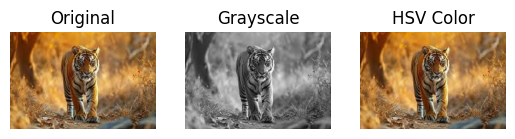

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV Color")
plt.axis("off")

plt.show()


## Drawing Shapes & Text on Image

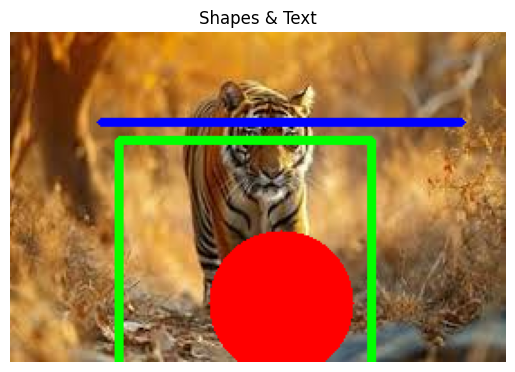

In [5]:
img_shapes = img.copy()

cv2.line(img_shapes, (50, 50), (250, 50), (255, 0, 0), 3)

cv2.rectangle(img_shapes, (60, 60), (200, 200), (0, 255, 0), 3)

cv2.circle(img_shapes, (150, 150), 40, (0, 0, 255), -1)   

cv2.putText(img_shapes, "OpenCV", (70, 250), cv2.FONT_HERSHEY_SIMPLEX, 
            1, (255, 255, 255), 2)

plt.imshow(cv2.cvtColor(img_shapes, cv2.COLOR_BGR2RGB))
plt.title("Shapes & Text")
plt.axis("off")
plt.show()


## Image Thresholding & Edge Detection

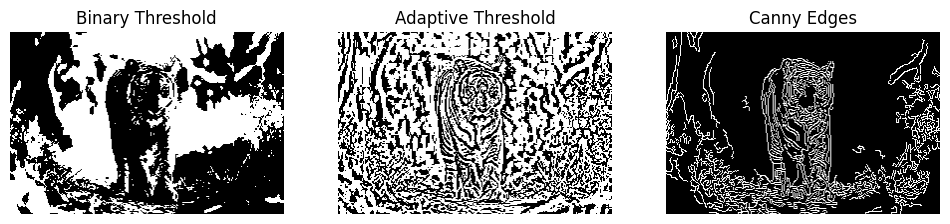

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

adaptive = cv2.adaptiveThreshold(gray, 255, 
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                 cv2.THRESH_BINARY, 11, 2)

edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(thresh, cmap="gray")
plt.title("Binary Threshold")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()


## Contours & Shape Detection

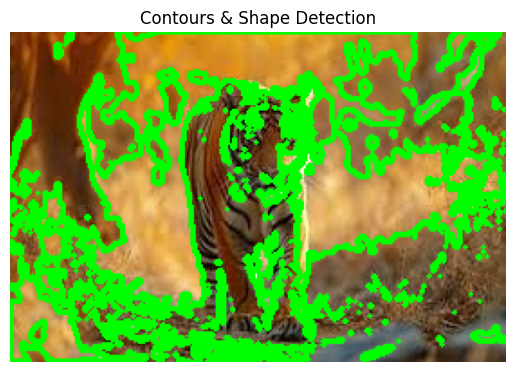

Number of contours detected: 360


In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title("Contours & Shape Detection")
plt.axis("off")
plt.show()

print("Number of contours detected:", len(contours))


## Face Detection (Haar Cascade)

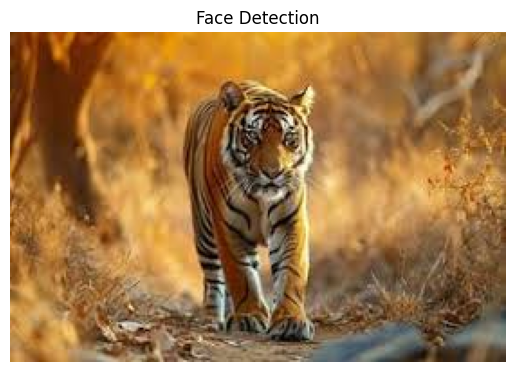

Number of faces detected: 0


In [8]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

img_faces = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_faces, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(img_faces, cv2.COLOR_BGR2RGB))
plt.title("Face Detection")
plt.axis("off")
plt.show()

print("Number of faces detected:", len(faces))
